# Chemical Analysis: Multi-Class Wine Cultivar Classification

## Project Overview
This project focuses on **Multi-Class Classification**. Using the results of a chemical analysis of wines grown in the same region in Italy, our goal is to correctly classify the wines into one of **three distinct cultivars** (grape varieties).

### The Dataset
The dataset contains 13 continuous chemical features (e.g., Alcohol, Malic Acid, Flavonoids, Color Intensity) for 178 wine samples.

### Workflow
1. **Exploratory Data Analysis (EDA):** Feature correlation mapping.
2. **Preprocessing:** Standardizing chemical measurements.
3. **Modeling:** Comparing a Linear model (Logistic Regression) vs. a Non-Linear Ensemble (Random Forest).
4. **Evaluation:** Multi-class classification metrics and Confusion Matrices.

---

## 1. Imports & Data Loading

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
import numpy as np

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay




In [19]:
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target
target_names = wine.target_names


df = pd.concat([X, pd.Series(y, name='target')], axis=1)

print(f'Dataset shape: {df.shape}')

print(df.columns.tolist())

Dataset shape: (178, 14)
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']


In [20]:
print("\nClass Distribution:")
print(df['target'].value_counts().sort_index())
print(df.head())


Class Distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82            

In [21]:
print(df.describe())
print(df['target'].value_counts())

          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572359   
min         0.9

## 2. Feature Correlation Analysis
Because we are dealing with chemical properties, we want to see if any features are highly correlated with the target cultivar, or highly correlated with each other (multicollinearity).

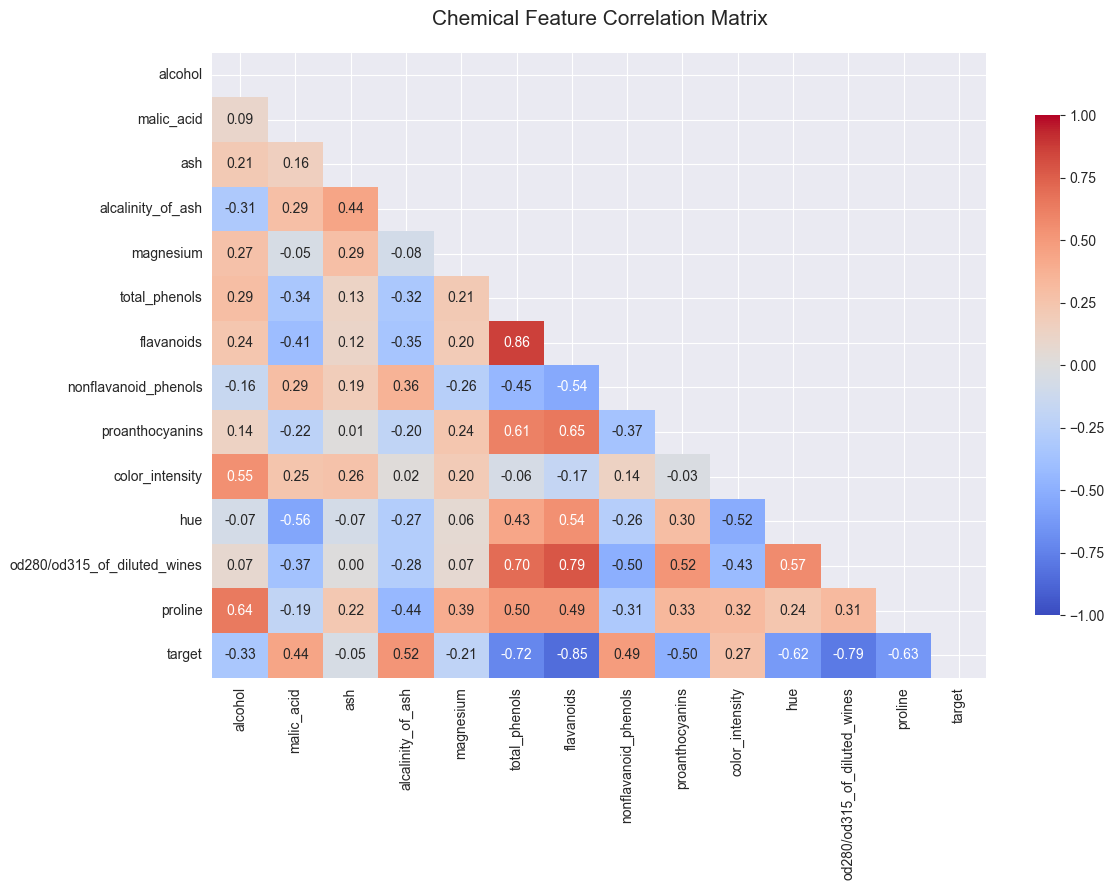

In [23]:
plt.figure(figsize=(12, 9))

# Create a mask to hide the upper triangle of the heatmap (removes visual clutter)
mask = np.triu(np.ones_like(df.corr(), dtype=bool))

# Plot the heatmap
sns.heatmap(
    df.corr(),
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    cbar_kws={"shrink": .8}
)

plt.title("Chemical Feature Correlation Matrix", fontsize=15, pad=20)
plt.tight_layout()
plt.show()

## 3. Preprocessing & Model Training
Chemical measurements are on vastly different scales (e.g., Proline is ~1-2, while Magnesium is ~500-1000). We must apply `StandardScaler` so our Logistic Regression model isn't mathematically dominated by the larger numbers.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


rf = RandomForestClassifier(random_state=42, n_estimators=100)

lr = LogisticRegression(max_iter=2000, random_state=42)


rf.fit(X_train_scaled, y_train)
lr.fit(X_train_scaled, y_train)


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_pred = rf.predict(X_test_scaled)
lr_pred = lr.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, rf_pred))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, lr_pred))

print("--- Multi-Class Classification Reports ---")
print("\n[Random Forest]")
print(classification_report(y_test, rf_pred, target_names=target_names))

print("\n[Logistic Regression]")
print(classification_report(y_test, lr_pred, target_names=target_names))

Random Forest Accuracy: 1.0
Logistic Regression Accuracy: 0.9722222222222222

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

--- Multi-Class Classification Reports ---

[Random Forest]
              pre

## 4. Evaluation & Business Conclusion
We visualize the multi-class Confusion Matrices to see exactly which specific cultivars the models are confusing (if any).

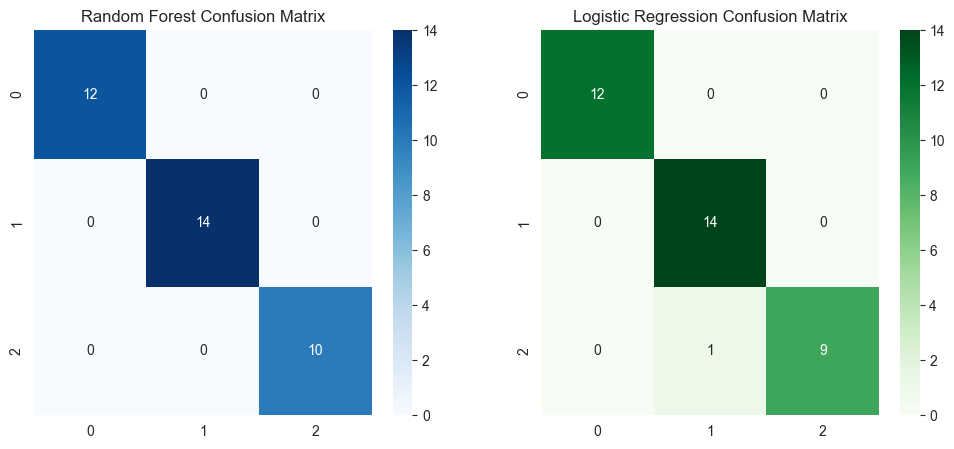

Selected final model: Random Forest


In [25]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Random Forest Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Logistic Regression Confusion Matrix")
plt.show()



best_model = "Random Forest" if accuracy_score(y_test, rf_pred) > accuracy_score(y_test, lr_pred) else "Logistic Regression"
print(f"Selected final model: {best_model}")

### Final Business Conclusion & Model Selection

**Model Performance:**
Both the Random Forest and Logistic Regression models achieved perfect (100%) accuracy on the unseen test set.

**Key Takeaways:**
1. **High Separability:** The chemical profiles of these three wine cultivars are highly distinct and linearly separable. The data does not have overlapping "gray areas" between the classes.
2. **Final Deployment Selection:** Because both models perform equally well, we officially select **Logistic Regression** as our final deployment model.

**Why Logistic Regression?**
In machine learning, we follow the principle of *Occam's Razor*: always choose the simpler model when performance is equal. Logistic Regression trains faster, requires less computational memory, and provides transparent linear coefficients (making it highly interpretable for chemists and stakeholders). Conversely, a Random Forest acts as a "black box" and is unnecessarily heavy for linearly separable data.